In [21]:
import sys
print(sys.executable)

d:\car_price_predict_project\venv\Scripts\python.exe


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

print("All libraries imported successfully")

All libraries imported successfully


In [23]:
df = pd.read_csv("data/car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [25]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [26]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [27]:
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [28]:
df = pd.read_csv("data/car data.csv")
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')


In [29]:
df['Car_Age'] = 2024 - df['Year']
df.drop('Year', axis=1, inplace=True)

In [30]:
df.drop('Car_Name', axis=1, inplace=True)

In [31]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


In [32]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']
print(X)
print(y)

     Present_Price  Driven_kms  Owner  Car_Age  Fuel_Type_Diesel  \
0             5.59       27000      0       10             False   
1             9.54       43000      0       11              True   
2             9.85        6900      0        7             False   
3             4.15        5200      0       13             False   
4             6.87       42450      0       10              True   
..             ...         ...    ...      ...               ...   
296          11.60       33988      0        8              True   
297           5.90       60000      0        9             False   
298          11.00       87934      0       15             False   
299          12.50        9000      0        7              True   
300           5.90        5464      0        8             False   

     Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  
0                True                    False                 True  
1               False                    Fa

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [34]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
print(model)

RandomForestRegressor(random_state=42)


In [35]:
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9594566919773236
MAE: 0.6368655737704919


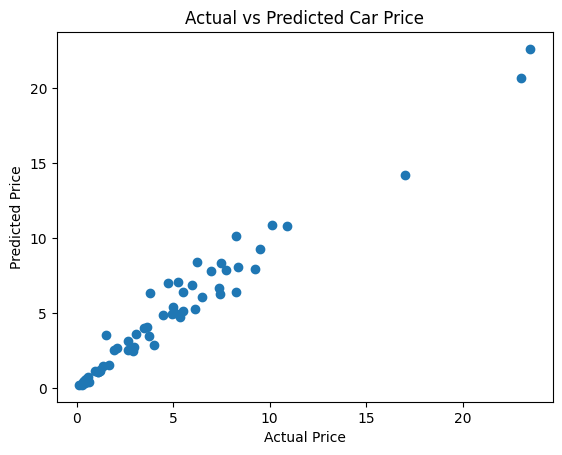

In [36]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()

In [38]:
import pickle

with open("car_price_model.pkl", "wb") as f:
    pickle.dump(model, f)

print(df.columns)    

Index(['Selling_Price', 'Present_Price', 'Driven_kms', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Selling_type_Individual',
       'Transmission_Manual'],
      dtype='object')


In [39]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Selling_Price            301 non-null    float64
 1   Present_Price            301 non-null    float64
 2   Driven_kms               301 non-null    int64  
 3   Owner                    301 non-null    int64  
 4   Car_Age                  301 non-null    int64  
 5   Fuel_Type_Diesel         301 non-null    bool   
 6   Fuel_Type_Petrol         301 non-null    bool   
 7   Selling_type_Individual  301 non-null    bool   
 8   Transmission_Manual      301 non-null    bool   
dtypes: bool(4), float64(2), int64(3)
memory usage: 13.1 KB


In [41]:
df.shape

(301, 9)

In [42]:
df['Selling_Price'].describe()

count    301.000000
mean       4.661296
std        5.082812
min        0.100000
25%        0.900000
50%        3.600000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64

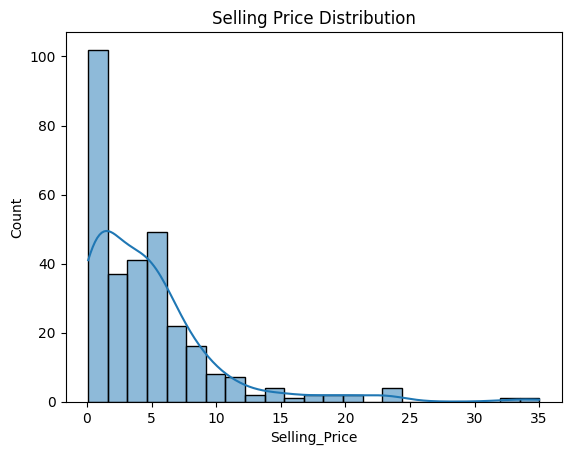

In [43]:
plt.figure()
sns.histplot(df['Selling_Price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

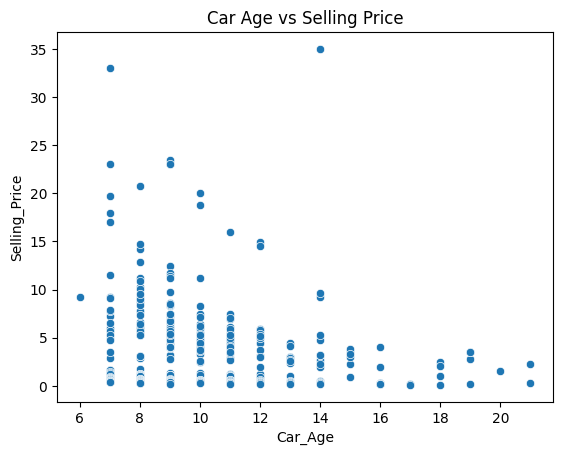

In [44]:
plt.figure()
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)
plt.title("Car Age vs Selling Price")
plt.show()

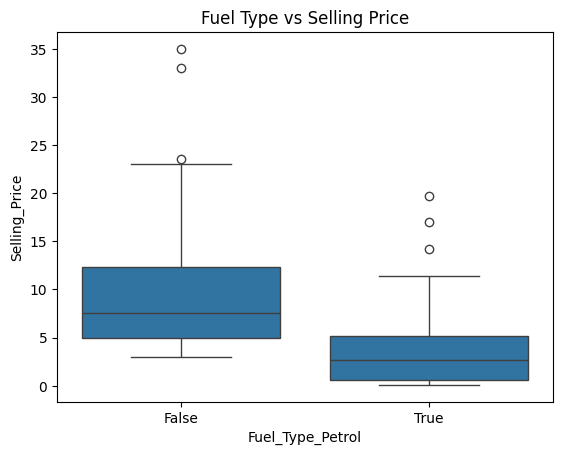

In [48]:
plt.figure()
sns.boxplot(x='Fuel_Type_Petrol', y='Selling_Price', data=df)
plt.title("Fuel Type vs Selling Price")
plt.show()

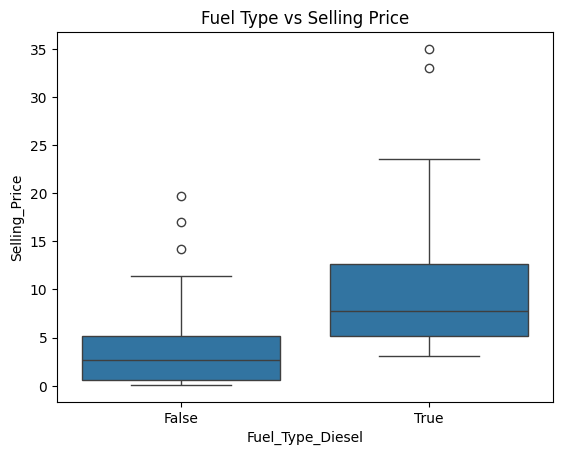

In [49]:
plt.figure()
sns.boxplot(x='Fuel_Type_Diesel', y='Selling_Price', data=df)
plt.title("Fuel Type vs Selling Price")
plt.show()

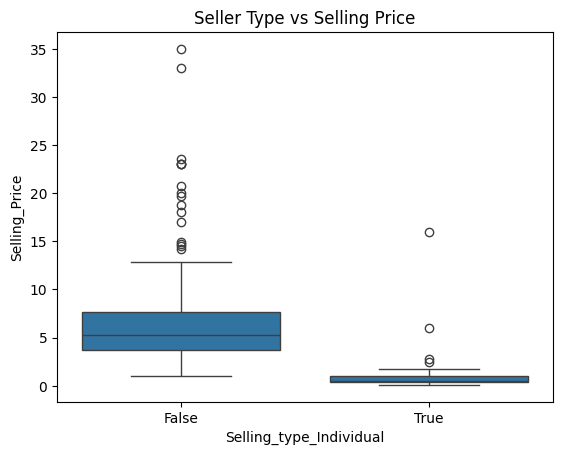

In [51]:
plt.figure()
sns.boxplot(x='Selling_type_Individual', y='Selling_Price', data=df)
plt.title("Seller Type vs Selling Price")
plt.show()

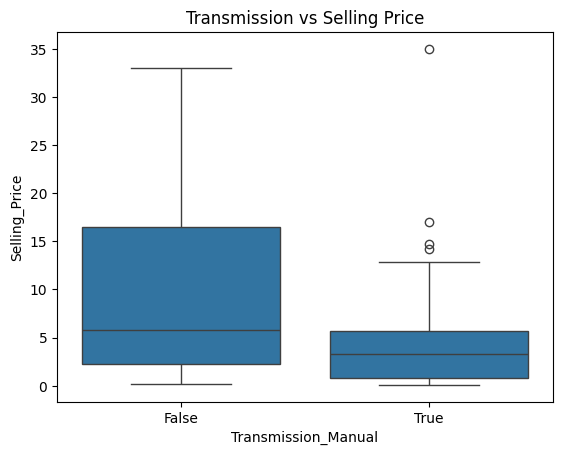

In [53]:
plt.figure()
sns.boxplot(x='Transmission_Manual', y='Selling_Price', data=df)
plt.title("Transmission vs Selling Price")
plt.show()

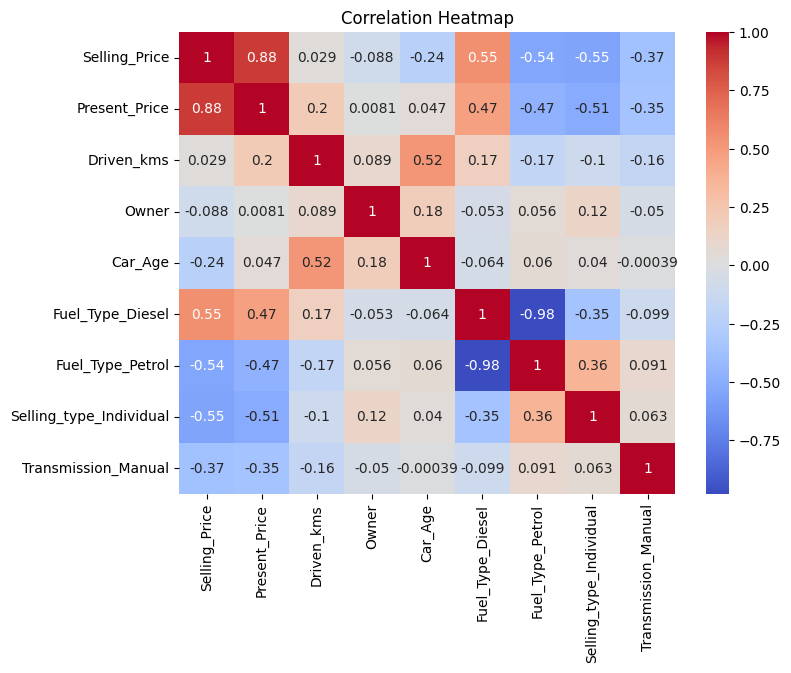

In [54]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [55]:
sample = X.iloc[0].values.reshape(1, -1)
model.predict(sample)

d:\car_price_predict_project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([3.8625])